# 0) Imports

In [24]:
import os
import sys
import glob
import json
import math
import time
import pdb
import pandas as pd
import numpy as np
import seaborn as sns
from tqdm import tqdm
from matplotlib import pyplot as plt
from pathlib import Path
from pathml.core import HESlide
from sklearn.utils import resample
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
from sklearn.model_selection import RepeatedKFold, RepeatedStratifiedKFold

sys.path.append('/mnt/scripts/biliseq_he_class2')
from helpers import anno as annoHelper
%load_ext autoreload
%autoreload 2

model_path = Path('/mnt/data/biliseq_he_class/models')
results = Path('/mnt/results')
sampleinfo = Path('/mnt/sampleinfo')
v6_path=Path('/mnt/data/biliseq_he_class/proc/v6/') #flatten to /mnt/data/proc/v6
tiles_path=v6_path.joinpath('tiles') # this should be updated to tiles_500px!
raw = Path('/mnt/data/biliseq_he_class/raw/new_data_20220829') #When all the wrinkles are worked out, flatten to /mnt/data/raw
svs = [str(x.parts[-1]) for x in raw.glob('*.svs')]
anno = Path('/mnt/data/biliseq_he_class/annotations/') #result? sampleinfo? flatten
# info = pd.read_csv(sampleinfo.joinpath('new_data_20220829_diagnosis_data_with_anno_v3.tsv'),
#                                       sep = '\t')

info = pd.read_csv(sampleinfo.joinpath('new_data_20220829_diagnosis_data_438_with_anno_v4.tsv'),
                                      sep = '\t')

models = Path('/mnt/results/v8/models')
thresh = 10
# fn = results.joinpath('malig_v8_224px_tiles_gt_%d_overlap_v2.tsv' % thresh) 
fn = results.joinpath('v8/anno/merged_v8_25636_224px_tiles_gt_10_overlap_v3.tsv')
malig = pd.read_csv(fn, sep = '\t')

#note: These are generated in this notebook below, so comment if updating etc:
slide_df = pd.read_csv(sampleinfo.joinpath('slide_df_v8.0_76_v4.tsv'),sep='\t').drop(columns=['Unnamed: 0'])
tile_df = pd.read_csv(sampleinfo.joinpath('tile_df_v8.0_298007_v4.tsv'),
                      dtype='str',
                      sep='\t')
print('Finished')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Finished


In [3]:
tile_df.head()

,fn,slide,case,class
0,/mnt/results/v8/tiles/224px/1007831/1007831_n3...,1007831,PHS15-7377,malig
1,/mnt/results/v8/tiles/224px/1007831/1007831_n3...,1007831,PHS15-7377,malig
2,/mnt/results/v8/tiles/224px/1007831/1007831_n3...,1007831,PHS15-7377,malig
3,/mnt/results/v8/tiles/224px/1007831/1007831_n3...,1007831,PHS15-7377,malig
4,/mnt/results/v8/tiles/224px/1007831/1007831_n3...,1007831,PHS15-7377,malig


# 1) Generate 'slide_df' dataframe of training set

In [56]:
idx = ~info.anno_class.isna()
version = 4 #4 - Add case column
            #3 - Adding annotations 12/2022 
            #2 - Updated typos and slides as of 9/30/22
slide_df = info.loc[idx,:].reset_index(drop=True)
slide_df.loc[:,'class'] = slide_df.path_pos.values
slide_df.loc[:,'slide'] = slide_df.slide_num
slide_df.loc[:,'case'] = slide_df.phs

slide_df.loc[slide_df.loc[:,'class'].values,'group'] = 'malig'
slide_df.loc[slide_df.loc[:,'class'].values==False,'group'] = 'benign'
# slide_df.loc[:,'class'] = slide_df.loc[:,'group']

fn = sampleinfo.joinpath('slide_df_v8.0_%d_v%d.tsv' % (slide_df.shape[0], version))
print(fn)
slide_df.to_csv(fn,sep = '\t',index = 'slide')
print(slide_df.shape)

pv = pd.pivot_table(slide_df, index = 'group', values = 'case',
                    columns='path_pos',
                    aggfunc='count')
pv

/mnt/sampleinfo/slide_df_v8.0_76_v4.tsv
(76, 20)


path_pos,False,True
group,,
benign,31.0,NaN
malig,NaN,45.0


In [57]:
slide_df.head()

,accession_number,pathologic_diagnosis,dob,location,follow_up_diagnosis,notes,phs,section_num,slide_num,fu_pos,path_pos,anno_fn,anno_class,raw_fn,anno_pnfn,tile_pn,class,slide,case,group
0,PHS15-7377 - 1007831,Adenocarcinoma,8/1/1957,Hilar,Intrahepatic Cholangiocarcinoma,NaN,PHS15-7377,NaN,1007831,True,True,1007831,malignant,PHS15-7377 - 1007831.svs,/mnt/data/biliseq_he_class/annotations/maligna...,/mnt/results/v8/tiles/224px/1007831,True,1007831,PHS15-7377,malig
1,PHS15-7510 - 1010330,Negative for Adenocarcinoma,12/9/1985,Distal,Benign Stricture,NaN,PHS15-7510,NaN,1010330,False,False,1010330,benign,PHS15-7510 - 1010330.svs,/mnt/data/biliseq_he_class/annotations/benign_...,/mnt/results/v8/tiles/224px/1010330,False,1010330,PHS15-7510,benign
2,PHS15-9836 - 1007828,Adenocarcinoma,12/30/1949,Hilar,Intrahepatic Cholangiocarcinoma,NaN,PHS15-9836,NaN,1007828,True,True,1007828,malignant,PHS15-9836 - 1007828.svs,/mnt/data/biliseq_he_class/annotations/maligna...,/mnt/results/v8/tiles/224px/1007828,True,1007828,PHS15-9836,malig
3,PHS15-29884 - 1010333,Negative for Adenocarcinoma,5/30/1955,Distal,Benign Stricture,NaN,PHS15-29884,NaN,1010333,False,False,1010333,benign,PHS15-29884 - 1010333.svs,/mnt/data/biliseq_he_class/annotations/benign_...,/mnt/results/v8/tiles/224px/1010333,False,1010333,PHS15-29884,benign
4,PHS16-5752 - 1010328,Negative for Adenocarcinoma,11/28/1959,Distal,Benign Stricture,NaN,PHS16-5752,NaN,1010328,False,False,1010328,benign,PHS16-5752 - 1010328.svs,/mnt/data/biliseq_he_class/annotations/benign_...,/mnt/results/v8/tiles/224px/1010328,False,1010328,PHS16-5752,benign


# 2) Generate training tile_df dataframe

In [21]:
all_dat = {'fn':[], 'slide':[], 'case':[], 'class':[]}
slide_classes = ['benign','malig']
version = 4 #Include case number
            # With 3, updated 12/22
for i,slide in enumerate(tqdm(slide_df.slide_num.values)):
    slide_class = slide_classes[int(slide_df.path_pos[i])]
    case = slide_df.case[i]
    tile_path = results.joinpath('v8/tiles/224px/%s' % slide)
    if slide_class == 'benign':
        all_tiles = [str(x) for x in tile_path.glob('*.jpg')]
    else:
        idx = malig.slide.str.contains(slide)
        # print(np.sum(idx),'Malig tiles',slide)
        all_tiles = [str(tile_path.joinpath(x)) for x in malig.tile[idx]] # just the annotated malignant tiles
    all_dat['fn'].extend(all_tiles)
    all_dat['slide'].extend([slide] * len(all_tiles))
    all_dat['class'].extend([slide_class] * len(all_tiles))
    all_dat['case'].extend([case] * len(all_tiles))
    
tile_df = pd.DataFrame(all_dat)    
fn = sampleinfo.joinpath('tile_df_v8.0_%d_v%d.tsv' % (tile_df.shape[0],
                                                      version))

print(fn)
tile_df.to_csv(fn,sep = '\t',index=False)
print(tile_df.shape)
tile_df.head(2)

100%|██████████| 76/76 [00:04<00:00, 18.67it/s]


/mnt/sampleinfo/tile_df_v8.0_298007_v4.tsv
(298007, 4)


,fn,slide,case,class
0,/mnt/results/v8/tiles/224px/1007831/1007831_n3...,1007831,PHS15-7377,malig
1,/mnt/results/v8/tiles/224px/1007831/1007831_n3...,1007831,PHS15-7377,malig


In [40]:
len(tile_df.case.unique())

50

# 3.0) print inputs for make_crossval_csv_v8.py

In [89]:
%%bash
cat ../model_fitting/cross_valid/make_crossval_csv_v8.py | head -n 38

'''
    make_crossval_csv_vy.py - script for generating tile-level crossvalidation .csv files
    for training and testing machine vision models. v7 extends capability to generate CV-compatible
    set of .csv for use with new test set (i.e. if many models were generated during training, use them
    to predict a new dataset entirely).

    inputs: $1 - split_data_path, str, path to use for train/validation spreadsheet(s)
                e.g. /ix/rbao/Projects/[...]/results/v8/tiles/224px
                Note: should be same directory used for training models if fold_method == 'crossvalid'
                      should be new data directory with same structure if fold_method == 'newdata'
            $2 - use_model, str describing model and cross-validation to perform
                e.g. 'resnet18_10fold_10rep_500bal_5ft'
                     arch_cvmethod_nreps_nbalance_nft -> parsed as parameters for CV
                    -architecture = 'resnet18'
                    -cv method = '1

# 3.1)Use make_crossval_csv_v8.py to generate 10 fold CV set

 Test kfold method

In [33]:
slide_df.loc[slide_test_idx,'class']

1     False
8      True
19     True
56    False
57     True
72     True
Name: class, dtype: bool

In [37]:
# splitter = RepeatedKFold(n_splits=2,
#                          n_repeats=1,
#                          random_state=35)

splitter =StratifiedGroupKFold(n_splits=10,
                              shuffle = True,
                              random_state=35)

for slide_train_idx, slide_test_idx in splitter.split(slide_df,
                                                      slide_df.loc[:, 'class'],
                                                      groups=slide_df.loc[:, 'case']):
    valid_cases = slide_df.loc[slide_test_idx,'case'].unique()
    # print(valid_cases)
    train_cases = slide_df.loc[slide_train_idx,'case'].unique()
    # print(train_cases)
    npos = slide_df.loc[slide_test_idx,'class'].sum() / len(slide_test_idx)
    print(len(train_cases),len(valid_cases),npos)
    print('Validation cases in training (should be 0): ',pd.Series(train_cases).isin(valid_cases).sum())

46 4 0.0
Validation cases in training (should be 0):  0
46 4 0.25
Validation cases in training (should be 0):  0
45 5 0.8235294117647058
Validation cases in training (should be 0):  0
46 4 0.25
Validation cases in training (should be 0):  0
45 5 0.8461538461538461
Validation cases in training (should be 0):  0
45 5 0.6
Validation cases in training (should be 0):  0
45 5 0.6
Validation cases in training (should be 0):  0
44 6 0.6
Validation cases in training (should be 0):  0
44 6 0.2857142857142857
Validation cases in training (should be 0):  0
44 6 0.6666666666666666
Validation cases in training (should be 0):  0


In [58]:
%%bash
SRC="/mnt/results/v8/tiles/224px"
MODEL="densenet169_10fold_1rep_1000bal_224px_v4"
FOLD="crossvalid"
# SLIDE_DF="/mnt/sampleinfo/slide_df_v8.0_44.tsv"
SLIDE_DF="/mnt/sampleinfo/slide_df_v8.0_76_v4.tsv"
# TILE_DF="/mnt/sampleinfo/tile_df_v8.0_255347.tsv"
TILE_DF="/mnt/sampleinfo/tile_df_v8.0_298007_v4.tsv"
/opt/conda/envs/py38/bin/python -u \
    ../model_fitting/cross_valid/make_crossval_csv_v9.py \
    $SRC $MODEL $FOLD $SLIDE_DF $TILE_DF

densenet169 10fold 1rep 1000bal 224px v4
Using 10fold cross-validation and fold # used as seed for fold-level resampling.
Version 4.
Positive class detected as malig.
With 35 random_state and 10 splits/folds

Fold 0
Train slides n=45 pos, 26 neg, Validation slides n=0 pos, 5 neg
Validation cases in training (should be 0):  0
	 pre rebalance: median n tiles / case train = 2106.0
	 after rebalance: median n tiles / case train = 1000.0
Balancing train tiles... 25238 neg 34198 pos, use 25238
	 pre rebalance: median n tiles / case valid = 6024.0
	 after rebalance: median n tiles / case valid = 1000.0
Balancing valid tiles... 5000 neg 0 pos, use 5000
if nbal > 0, n_pos = 25238 (should ==) n_neg= 25238
Save to /mnt/results/v8/models/densenet169_10fold_1rep_1000bal_224px_v4/csv/train_valid_fold_0.csv

Fold 1
Train slides n=44 pos, 28 neg, Validation slides n=1 pos, 3 neg
Validation cases in training (should be 0):  0
	 pre rebalance: median n tiles / case train = 2808.5
	 after rebalance: medi

# 4) Examine a file

In [59]:
models = Path('/mnt/results/v8/models')
# fn = models.joinpath('resnet18_10fold_1rep_0bal_2ft/csv/train_valid_fold_9.csv')
# fn = models.joinpath('resnet18_10fold_1rep_250bal_2ft/csv/train_valid_fold_8.csv') 
fn = models.joinpath('densenet169_10fold_1rep_1000bal_224px_v4/csv/train_valid_fold_1.csv')
# fn = models.joinpath('densenet169_10fold_1rep_500bal_2ft/csv/train_valid_fold_8.csv')
df = pd.read_csv(fn).drop(columns = ['Unnamed: 0'])
print(df.shape)
print('Valid:',np.sum(df.is_valid))
print('Malig:',df.loc[:,'class'].str.contains('malig').sum())
idx = df.loc[:,'class'].str.contains('malig') & ~df.is_valid.values
print('Malig & Train:', np.sum(idx))
idx = df.loc[:,'class'].str.contains('benign') & ~df.is_valid.values
print('Benign & Train:', np.sum(idx))
idx = df.loc[:,'class'].str.contains('malig') & df.is_valid.values
print('Malig & Test:', np.sum(idx))
idx = df.loc[:,'class'].str.contains('benign') & df.is_valid.values
print('Benign & Test:', np.sum(idx))
# val_slides = df.loc[df.is_valid.values==1,'slide'].unique()
# print(val_slides)
valid_cases = df.loc[df.is_valid.values==1,'case'].unique()
print(valid_cases)
train_cases = df.loc[df.is_valid.values==0,'case'].unique()
print(train_cases)
print('Validation cases in training (should be 0): ',pd.Series(train_cases).isin(valid_cases).sum())
df.head()

(54884, 6)
Valid: 408
Malig: 27442
Malig & Train: 27238
Benign & Train: 27238
Malig & Test: 204
Benign & Test: 204
['PHS21-30495 ' 'PHS20-27395 ' 'PHS16-5752 ' 'PHS19-19316 ']
['PHS15-7510 ' 'PHS15-29884 ' 'PHS16-15556 ' 'PHS16-19238 ' 'PHS17-176 '
 'PHS17-23147 ' 'PHS17-29036 ' 'PHS17-39283 ' 'PHS18-14380 '
 'PHS21-22367 ' 'PHS21-23251 ' 'PHS21-30602 ' 'PHS21-32598 ' 'PHS20-9707 '
 'PHS20-14920 ' 'PHS20-17251 ' 'PHS20-21501 ' 'PHS20-25176 '
 'PHS20-27580 ' 'PHS20-27880 ' 'PHS20-29954 ' 'PHS20-32025 '
 'PHS20-32069 ' 'PHS21-408 ' 'PHS21-1568 ' 'PHS22-23675' 'PHS20-28859 '
 'PHS17-9700 ' 'PHS20-32867 ' 'PHS20-32143 ' 'PHS20-25327 ' 'PHS21-5163 '
 'PHS20-9658 ' 'PHS20-16994 ' 'PHS16-30091 ' 'PHS16-42277 ' 'PHS21-24642 '
 'PHS20-33407 ' 'PHS17-16672 ' 'PHS21-24702 ' 'PHS19-11117 '
 'PHS19-13228 ' 'PHS20-35461 ' 'PHS15-7377 ' 'PHS15-9836 ' 'PHS16-29893 ']
Validation cases in training (should be 0):  0


,fn,slide,case,class,is_valid,full_path
0,1010330_n103885_x8288_y147952_px224.jpg,1010330,PHS15-7510,benign,0,/mnt/results/v8/tiles/224px/1010330/1010330_n1...
1,1010330_n116504_x9408_y8960_px224.jpg,1010330,PHS15-7510,benign,0,/mnt/results/v8/tiles/224px/1010330/1010330_n1...
2,1010330_n140062_x11312_y8512_px224.jpg,1010330,PHS15-7510,benign,0,/mnt/results/v8/tiles/224px/1010330/1010330_n1...
3,1010330_n92404_x7392_y103936_px224.jpg,1010330,PHS15-7510,benign,0,/mnt/results/v8/tiles/224px/1010330/1010330_n9...
4,1010330_n101234_x8176_y6272_px224.jpg,1010330,PHS15-7510,benign,0,/mnt/results/v8/tiles/224px/1010330/1010330_n1...


In [60]:
df.groupby(['is_valid','slide','class'])['fn'].count()

is_valid  slide                class 
0         1007468              benign    1000
          1007469              benign    1000
          1007470              benign    1000
          1007471              benign    1000
          1007473              benign    1000
                                         ... 
          PHS22-23675 - 1 - 9  malig      517
1         1007467              benign      68
          1007486              malig      204
          1010165              benign      66
          1010328              benign      70
Name: fn, Length: 76, dtype: int64

In [25]:
new_fns=[]
path = Path('/ix/rbao/Projects')
for img_fn in df.fn:
    temp = img_fn.split('.')[0]
    px = temp.split('_')[-1].split('px')[1] + 'px'
    slide = temp.split('_')[0]
    new_fns.append(str(path.joinpath('tiles').joinpath(px).joinpath(slide).joinpath(img_fn)))
print(new_fns[0:2])

['/ix/rbao/Projects/tiles/224px/1007847/1007847_n328071_x40544_y11088_px224.jpg', '/ix/rbao/Projects/tiles/224px/1007468/1007468_n207275_x17360_y91280_px224.jpg']


# 5) Make training/validation set that uses all data and very small validation set (Full model)
Idea here is that this can be the finalized model for use on large validation set outside of training set

Also: might be useful in training set to create a new type of model: from tile organization to WSI prediction

(177333, 6)
(27590, 6)
(200,) Int64Index([214484, 51655, 390452, 212954, 271180, 565374, 51642, 157416,
            447236, 157613],
           dtype='int64')
0
200
[20542, 156591]
(136049,)
200
[20542, 20542]
57 143
/mnt/results/v8/models/densenet169_1fold_1rep_20542bal_224px_v4/csv/train_valid_fold_0.csv


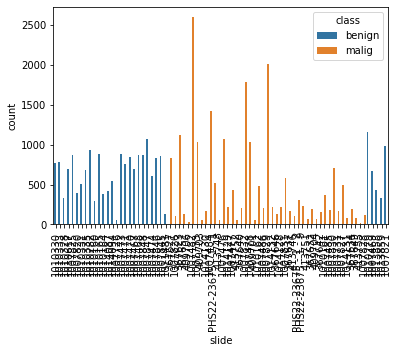

In [61]:
csv_path= models.joinpath('densenet169_10fold_1rep_1000bal_224px_v4/csv') #Tile examples are balanced --> densenets may do better
all_folds = pd.DataFrame([])
for fold in range(0,10):
    df=pd.read_csv(csv_path.joinpath('train_valid_fold_%d.csv' % fold)).drop(columns='Unnamed: 0')
    all_folds = pd.concat((all_folds,df))
all_folds.reset_index(drop=True,inplace=True)
all_folds=all_folds.drop_duplicates()
print(all_folds.shape)
is_val = all_folds.loc[:,'is_valid'].values == 1
test = all_folds.loc[is_val,:]
print(test.shape)
seed=35
smaller_test = resample(test.index,
                       replace=False,
                       n_samples=200,
                       random_state=seed)
print(smaller_test.shape,smaller_test[0:10])

all_folds.loc[:,'is_valid'] = 0
is_val = all_folds.loc[:,'is_valid'].values == 1
print(np.sum(is_val))
all_folds.loc[np.unique(smaller_test.values),'is_valid'] = 1

is_val = all_folds.loc[:,'is_valid'].values == 1
print(np.sum(is_val))
train_n= [np.sum(all_folds.loc[~is_val,'class'].str.contains('malig')),
      np.sum(all_folds.loc[~is_val,'class'].str.contains('benign'))]
print(train_n)
#Balance
is_benign = all_folds.loc[~is_val,'class'].str.contains('benign')
smaller_benign = resample(is_benign[is_benign.values==1].index,
                       replace=False,
                       n_samples=train_n[1]-train_n[0],
                       random_state=seed)
print(smaller_benign.shape)
all_folds = all_folds.drop(index=smaller_benign)
all_folds = all_folds.reset_index(drop=True)
is_val = all_folds.loc[:,'is_valid'].values == 1
print(np.sum(is_val))
train_n= [np.sum(all_folds.loc[~is_val,'class'].str.contains('malig')),
      np.sum(all_folds.loc[~is_val,'class'].str.contains('benign'))]
print(train_n)
print(np.sum(all_folds.loc[is_val,'class'].str.contains('malig')),
      np.sum(all_folds.loc[is_val,'class'].str.contains('benign')))
out_path= models.joinpath('densenet169_1fold_1rep_%dbal_224px_v4/csv' % train_n[0]) 
out_path.mkdir(parents=True, exist_ok=True)
sns.countplot(data=all_folds.loc[~is_val,:],
              x='slide',
              hue = 'class')
plt.xticks(rotation=90);
fn = out_path.joinpath('train_valid_fold_0.csv')
print(fn)
all_folds.to_csv(fn)

# 6) Run batch fitting with these files
see /ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/scripts/biliseq_he_class2/model_fitting/train

in particular: run_batch_slurm_fastai_cnn_fit_v2.sh